**6/29/2026**

**BreastDM_DataProcessing**

This notebook is going to be my notebook for all my data processing stuff. BreastDM_CW is just going to be general processing for other applications.

Currently the code in this ipynb file does:

*   Setup and Unzipping // It initializes by importing necessary libraries, mounts Google Drive, and unzips the main dataset from a .zip file.
*   Initial Data Inspection // The code then looks at the directory structure of the unzipped dataset and loads a sample .npy file to understand its data type, shape, and value range. This makes it easy to see how far I am and how far I need to go to make it the desired structure.
*   Classification Data Organization // Processes .npy files to organize them into distinct 'Benign' and 'Malignant' directories, preparing the data for a classification task.
*   Segmentation Data Processing and Visualization // Identifies 3D image and mask .npy volumes from the segmentation part of the dataset, extracts a central 2D slice from each, and displays these slices for visual inspection.
*   Segmentation Data Conversion // Finally, it converts these extracted 2D slices from .npy format into .png image files, scaling their pixel values, and saving them into separate 'images' and 'masks' directories for segmentation tasks.









In [13]:
# Imports
import os
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
import zipfile
import shutil
from PIL import Image


In [ ]:
# Mount

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Dataset path
DATASET = "/content/drive/MyDrive/BreastDMDS.zip"

# little testing

root = DATASET

max_depth = 3

for current_path, dirs, files in os.walk(root):

  # deepness?

  depth = current_path.replace(root,"").count(os.sep)
  if depth > max_depth:
      continue

      indent = "    "*depth

      # Folder name

      print(f"{indent}{os.path.basename(current_path)}/")

      # Print files from this folder

      file_indent = "    "*(depth+1)

      for file in files[:5]:
          print(f"{file_indent}{file}")
      # stop the spamming output
      if len(files) > 5:
          print(f'{file_indent}...({len(files)-5}) more files')

In [ ]:
# I have unzip the file first!

unzip_path = '/content/BreastDMDS_unzipped'
os.makedirs(unzip_path, exist_ok=True)

with zipfile.ZipFile(DATASET, 'r') as zip_ref:
    zip_ref.extractall(unzip_path)

print(f"Dataset unzipped to: {unzip_path}")

# Update DATASET to point to the unzipped directory
# DATASET = unzip_path

Dataset unzipped to: /content/BreastDMDS_unzipped


In [ ]:
# little testing (corrected)

root = unzip_path

def dir_structure(root,maxdepth):
    for current_path, dirs, files in os.walk(root):

        depth = current_path.replace(root, "").count(os.sep)

        if depth > maxdepth: # Corrected: using 'maxdepth' parameter
            continue

        indent = "    " * depth

        # Folder name
        print(f"{indent}{os.path.basename(current_path)}/")

        # Print files from this folder
        file_indent = "    " * (depth + 1)

        for file in files[:5]:
            print(f"{file_indent}{file}")
        # stop the spamming output
        if len(files) > 5:
            print(f'{file_indent}...({len(files)-5}) more files')

print("============================2 Depth============================")
dir_structure(unzip_path,2)
# print("============================4 Depth============================")
# dir_structure(unzip_path,4) # this is for a more in depth look (too deep for visualiztion)

============================2 Depth============================
BreastDMDS_unzipped/
    cls/
        GLCM/
        img17Se/
        img9Se/
        LBP/
    seg/
        val/
        train/
        test/
    seg3D/
        val/
        train/
        test/


In [ ]:
# Define the new root directory for the organized dataset
new_dataset_root = '/content/processed_dataset'
benign_dir = os.path.join(new_dataset_root, 'B')
malignant_dir = os.path.join(new_dataset_root, 'M')

# Create the new directories if they don't exist
os.makedirs(benign_dir, exist_ok=True)
os.makedirs(malignant_dir, exist_ok=True)

print(f"Created directories: {benign_dir} and {malignant_dir}")

# Iterate through the unzipped dataset to find and move .npy files
benign_count = 0
malignant_count = 0

for current_path, _, files in os.walk(unzip_path):
    for file_name in files:
        if file_name.endswith('.npy'):
            full_file_path = os.path.join(current_path, file_name)

            # Determine the classification from the path
            if 'Benign' in current_path:
                destination_path = os.path.join(benign_dir, file_name)
                shutil.move(full_file_path, destination_path)
                benign_count += 1
            elif 'Malignant' in current_path:
                destination_path = os.path.join(malignant_dir, file_name)
                shutil.move(full_file_path, destination_path)
                malignant_count += 1
            else:
                print(f"Warning: Could not classify file {full_file_path}. Skipping.")

print(f"\nFinished organizing files:")
print(f"  Moved {benign_count} Benign files to {benign_dir}")
print(f"  Moved {malignant_count} Malignant files to {malignant_dir}")

# DATASET is not updated here to maintain its independence.
print(f"\nNew dataset root for B/M classification: {new_dataset_root}")

Created directories: /content/processed_dataset/B and /content/processed_dataset/M

Finished organizing files:
  Moved 2790 Benign files to /content/processed_dataset/B
  Moved 7585 Malignant files to /content/processed_dataset/M

New dataset root for B/M classification: /content/processed_dataset


In [14]:
# Verify the new structure
# this is the same thing from the other cell that i printed the structure
# i just want to check to make sure it looks how i need it to

print("============================ Organized Dataset Structure ============================")
dir_structure(new_dataset_root, maxdepth=2)

print(f"\nTotal files in Benign folder: {len(os.listdir(os.path.join(new_dataset_root, 'B')))}")
print(f"Total files in Malignant folder: {len(os.listdir(os.path.join(new_dataset_root, 'M')))}")

============================ Organized Dataset Structure ============================
processed_dataset/
    M/
        p-039.npy
        p-091.npy
        p-071.npy
        p-026.npy
        p-057.npy
        ...(82) more files
    B/
        p-039.npy
        p-091.npy
        p-071.npy
        p-026.npy
        p-057.npy
        ...(73) more files

Total files in Benign folder: 78
Total files in Malignant folder: 87


In [ ]:
# Looking at files because how do we even differentiate between mask

# We need to find an actual .npy file path from the unzipped directory

sample_file_path = None
for root_dir, _, files in os.walk(unzip_path):
    for file_name in files:
        if file_name.endswith('.npy'):
            sample_file_path = os.path.join(root_dir, file_name)
            break
    if sample_file_path:
        break

if sample_file_path:
    print(f"Found sample .npy file in unzipped directory: {sample_file_path}")
    try:
        # Load the .npy file
        data = np.load(sample_file_path)

        print(f"\nData type of the loaded array: {data.dtype}")
        print(f"Shape of the loaded array: {data.shape}")
        print(f"Example values (first 5 elements if 1D, or a slice if multi-dimensional):\n{data.flatten()[:5] if data.ndim > 0 else data}")

        # If it's a 2D or 3D array, we can try to visualize it later
        if data.ndim >= 2:
            print(f"Min value: {data.min()}, Max value: {data.max()}")

    except Exception as e:
        print(f"Error loading or inspecting {sample_file_path}: {e}")
else:
    print(f"No .npy files found in {unzip_path}")

Found sample .npy file in unzipped directory: /content/BreastDMDS_unzipped/seg3D/val/labels/BreaDM-Be-2112/VIBRANT.npy

Data type of the loaded array: float64
Shape of the loaded array: (369, 369, 8)
Example values (first 5 elements if 1D, or a slice if multi-dimensional):
[0. 0. 0. 0. 0.]
Min value: 0.0, Max value: 255.0


Inspecting files from: /content/BreastDMDS_unzipped

Found sample image file: /content/BreastDMDS_unzipped/seg3D/val/images/BreaDM-Be-2112/VIBRANT.npy
Found sample mask file: /content/BreastDMDS_unzipped/seg3D/val/labels/BreaDM-Be-2112/VIBRANT.npy

Image Data type: float64
Image Shape: (369, 369, 8)
Image Min/Max: 0.0/255.0
Displaying a central slice of the image volume...


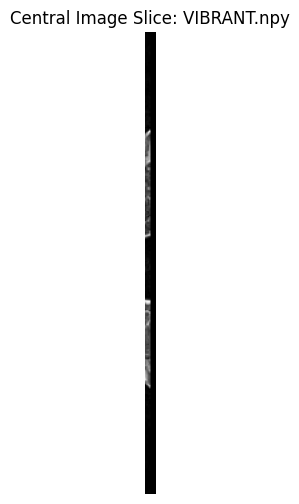


Mask Data type: float64
Mask Shape: (369, 369, 8)
Mask Min/Max: 0.0/255.0
Displaying a central slice of the mask volume...


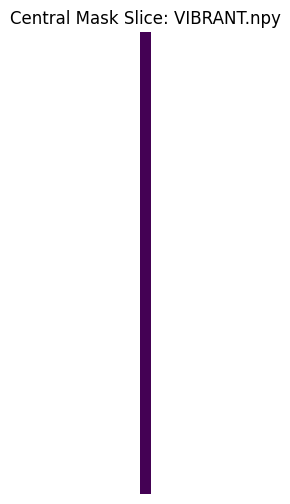

In [ ]:
# Use unzip_path as the source for inspection
print(f"Inspecting files from: {unzip_path}")

image_file_path = None
mask_file_path = None

# Search for a sample image .npy file
for root_dir, _, files in os.walk(unzip_path):
    if 'seg3D' in root_dir and 'images' in root_dir:
        for file_name in files:
            if file_name.endswith('.npy'):
                image_file_path = os.path.join(root_dir, file_name)
                break
    if image_file_path:
        break

# Search for a sample mask .npy file
for root_dir, _, files in os.walk(unzip_path):
    if 'seg3D' in root_dir and 'labels' in root_dir:
        for file_name in files:
            if file_name.endswith('.npy'):
                mask_file_path = os.path.join(root_dir, file_name)
                break
    if mask_file_path:
        break

print(f"\nFound sample image file: {image_file_path}")
print(f"Found sample mask file: {mask_file_path}")

if image_file_path:
    try:
        image_data = np.load(image_file_path)
        print(f"\nImage Data type: {image_data.dtype}")
        print(f"Image Shape: {image_data.shape}")
        print(f"Image Min/Max: {image_data.min()}/{image_data.max()}")

        # Attempt to display a slice if it's a 3D volume
        if image_data.ndim == 3:
            print("Displaying a central slice of the image volume...")
            plt.figure(figsize=(6, 6))
            plt.imshow(image_data[image_data.shape[0] // 2, :, :], cmap='gray')
            plt.title(f'Central Image Slice: {os.path.basename(image_file_path)}')
            plt.axis('off')
            plt.show()
        elif image_data.ndim == 2:
            print("Displaying the 2D image...")
            plt.figure(figsize=(6, 6))
            plt.imshow(image_data, cmap='gray')
            plt.title(f'Image: {os.path.basename(image_file_path)}')
            plt.axis('off')
            plt.show()

    except Exception as e:
        print(f"Error loading or displaying image file {image_file_path}: {e}")

if mask_file_path:
    try:
        mask_data = np.load(mask_file_path)
        print(f"\nMask Data type: {mask_data.dtype}")
        print(f"Mask Shape: {mask_data.shape}")
        print(f"Mask Min/Max: {mask_data.min()}/{mask_data.max()}")

        # Attempt to display a slice if it's a 3D volume
        if mask_data.ndim == 3:
            print("Displaying a central slice of the mask volume...")
            plt.figure(figsize=(6, 6))
            plt.imshow(mask_data[mask_data.shape[0] // 2, :, :], cmap='viridis') # Use a different colormap for masks
            plt.title(f'Central Mask Slice: {os.path.basename(mask_file_path)}')
            plt.axis('off')
            plt.show()
        elif mask_data.ndim == 2:
            print("Displaying the 2D mask...")
            plt.figure(figsize=(6, 6))
            plt.imshow(mask_data, cmap='viridis')
            plt.title(f'Mask: {os.path.basename(mask_file_path)}')
            plt.axis('off')
            plt.show()

    except Exception as e:
        print(f"Error loading or displaying mask file {mask_file_path}: {e}")
else:
    if not image_file_path and not mask_file_path:
        print("No .npy image or mask files found in 'seg3D/images' or 'seg3D/labels' directories.")

In [15]:
# Define the new root directory for the organized segmentation dataset
# this is very similar to how the other segmentation directories work
segmentation_dataset_root = '/content/segmentation_dataset'
images_dir = os.path.join(segmentation_dataset_root, 'images')
masks_dir = os.path.join(segmentation_dataset_root, 'masks')

# Create the new directories if they don't exist
os.makedirs(images_dir, exist_ok=True)
os.makedirs(masks_dir, exist_ok=True)

print(f"Created directories: {images_dir} and {masks_dir}")

print(f"Processing files from: {unzip_path}")

processed_count = 0

# Iterate through the unzipped dataset
for root_dir, _, files in os.walk(unzip_path):
    # Look for 'images' and 'labels' directories within 'seg3D' splits
    if 'seg3D' in root_dir and ('images' in root_dir or 'labels' in root_dir):
        # Determine if it's an image or a mask directory
        is_image_dir = 'images' in root_dir

        # Extract split and patient_id for unique filenames
        # Example root_dir: /content/BreastDMDS_unzipped/seg3D/val/images/BreaDM-Be-2005
        try:
            # Split the path into components
            path_components = root_dir.split(os.sep)
            # Find the index of 'seg3D'
            seg3d_idx = path_components.index('seg3D')

            # The split (train/val/test) is after 'seg3D'
            split = path_components[seg3d_idx + 1]

            # The patient ID is after 'images' or 'labels'
            # Check if patient ID exists (for cases where root_dir might be just images/ or labels/)
            if len(path_components) > seg3d_idx + 3:
                patient_id = path_components[seg3d_idx + 3]
            else:
                patient_id = "unknown_patient" # Fallback if structure is unexpected

        except ValueError: # 'seg3D' not found or path structure is not as expected
            split = "unknown_split"
            patient_id = "unknown_patient"
        except IndexError: # Not enough components after seg3d_idx
            split = "unknown_split"
            patient_id = "unknown_patient"


        for file_name in files:
            if file_name.endswith('.npy'):
                original_base_name = os.path.splitext(file_name)[0] # Get filename without extension
                full_npy_path = os.path.join(root_dir, file_name)

                try:
                    data = np.load(full_npy_path)

                    # Handle 3D volumes by taking a central slice
                    if data.ndim == 3:
                        # Assuming the last dimension is the number of slices
                        central_slice_idx = data.shape[2] // 2
                        processed_data = data[:, :, central_slice_idx]
                    elif data.ndim == 2:
                        processed_data = data
                    else:
                        print(f"Skipping {full_npy_path}: Unsupported number of dimensions ({data.ndim})")
                        continue

                    # Scale data to 0-255 and convert to uint8 for PNG
                    # Ensure min/max are not identical to avoid division by zero
                    data_min = processed_data.min()
                    data_max = processed_data.max()

                    if data_max == data_min:
                        # Handle cases where all pixel values are the same
                        scaled_data = np.zeros_like(processed_data, dtype=np.uint8)
                        if data_min > 0: # If it's a non-zero constant, set to max for visualization
                            scaled_data.fill(255)
                    else:
                        scaled_data = ((processed_data - data_min) / (data_max - data_min) * 255).astype(np.uint8)


                    # Create PIL Image
                    img = Image.fromarray(scaled_data)

                    # Generate unique filename including split and patient_id
                    unique_filename = f"{split}_{patient_id}_{original_base_name}.png"

                    # Define destination path
                    if is_image_dir:
                        destination_png_path = os.path.join(images_dir, unique_filename)
                    else:
                        destination_png_path = os.path.join(masks_dir, unique_filename)

                    # Save as PNG
                    img.save(destination_png_path)
                    processed_count += 1

                except Exception as e:
                    print(f"Error processing {full_npy_path}: {e}")

print(f"\nFinished processing. Converted and saved {processed_count} .png files to {segmentation_dataset_root}")
# DATASET variable is not updated here to maintain its independence.

Created directories: /content/segmentation_dataset/images and /content/segmentation_dataset/masks
Processing files from: /content/BreastDMDS_unzipped

Finished processing. Converted and saved 1410 .png files to /content/segmentation_dataset


In [16]:
# Verify the new structure
print("============================ New Segmentation Dataset Structure ============================")
def dir_structure(root, maxdepth):
    for current_path, dirs, files in os.walk(root):
        depth = current_path.replace(root, "").count(os.sep)
        if depth > maxdepth:
            continue
        indent = "    " * depth
        print(f"{indent}{os.path.basename(current_path)}/")
        file_indent = "    " * (depth + 1)
        for file in files[:5]:
            print(f"{file_indent}{file}")
        if len(files) > 5:
            print(f'{file_indent}...({len(files) - 5}) more files')


dir_structure(segmentation_dataset_root, maxdepth=2)

print(f"\nTotal image files: {len(os.listdir(os.path.join(segmentation_dataset_root, 'images')))}")
print(f"Total mask files: {len(os.listdir(os.path.join(segmentation_dataset_root, 'masks')))}")

============================ New Segmentation Dataset Structure ============================
segmentation_dataset/
    masks/
        test_BreaDM-Be-2019_VIBRANT.png
        test_BreaDM-Be-2113_SUB2.png
        train_BreaDM-Be-1805_SUB2.png
        train_BreaDM-Be-1809_SUB2.png
        train_BreaDM-Ma-2111_VIBRANT.png
        ...(709) more files
    images/
        test_BreaDM-Be-2019_VIBRANT.png
        test_BreaDM-Be-2113_SUB2.png
        train_BreaDM-Be-1805_SUB2.png
        train_BreaDM-Be-1809_SUB2.png
        train_BreaDM-Ma-2111_VIBRANT.png
        ...(691) more files

Total image files: 696
Total mask files: 714


In [17]:
# Copy to the google drive so i can use it in another colab session.
# I only care about this one, not BreastDMDS_unzipped, processed_dataset, segmentation_dataset
!cp -r /content/segmentation_dataset "/content/drive/MyDrive/BreastDM_Project/segmentation_dataset"